
<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
Digital Image Processing <br>
<font color=2565AE size=5>
Department Of Mathematical Sciences <br>
Spring 2025<br>
<font color=3C99D size=5>
Assignment 3 <br>
</div>


---



### Full Name :Kasra Siavashpour
### Student Number :99109903
___

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct, idct
import cv2
from PIL import Image

## Step 1: Divide image into 8x8 blocks and apply DCT
## (use realimage.jpg)

In [5]:
# Load and preprocess the image
def load_and_prepare_image(filename):
    """Load image and convert to grayscale if needed"""
    try:
        # Try loading with PIL first
        img = Image.open(filename)
        if img.mode != 'L':
            img = img.convert('L')
        image = np.array(img, dtype=np.float32)
    except:
        # Fallback to cv2
        image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
        image = image.astype(np.float32)
    
    # Subtract 128 to center around 0 (JPEG standard)
    image = image - 128
    
    # Pad image to make dimensions divisible by 8
    h, w = image.shape
    pad_h = (8 - h % 8) % 8
    pad_w = (8 - w % 8) % 8
    
    if pad_h > 0 or pad_w > 0:
        image = np.pad(image, ((0, pad_h), (0, pad_w)), mode='edge')
    
    return image

In [6]:
def apply_dct(image):
    """Divide image into 8x8 blocks and apply 2D DCT to each block"""
    h, w = image.shape
    
    # Calculate number of blocks
    num_blocks_h = h // 8
    num_blocks_w = w // 8
    
    # Initialize array to store DCT blocks
    dct_blocks = np.zeros((num_blocks_h, num_blocks_w, 8, 8))
    
    # Apply DCT to each 8x8 block
    for i in range(num_blocks_h):
        for j in range(num_blocks_w):
            # Extract 8x8 block
            block = image[i*8:(i+1)*8, j*8:(j+1)*8]
            
            # Apply 2D DCT using scipy
            dct_block = dct(dct(block.T, norm='ortho').T, norm='ortho')
            
            dct_blocks[i, j] = dct_block
    
    return dct_blocks

## Step 2: Quantization


In [7]:
# Quantization matrix (JPEG standard)
Z = np.array([[16,11,10,16,24,40,51,61],
              [12,12,14,19,26,58,60,55],
              [14,13,16,24,40,57,69,56],
              [14,17,22,29,51,87,80,62],
              [18,22,37,56,68,109,103,77],
              [24,35,55,64,81,104,113,92],
              [49,64,78,87,103,121,120,101],
              [72,92,95,98,112,100,130,99]])

In [8]:
def quantize(dct_blocks):
    """Quantize DCT coefficients by dividing by quantization matrix"""
    num_blocks_h, num_blocks_w, _, _ = dct_blocks.shape
    
    # Initialize quantized blocks array
    quantized_blocks = np.zeros_like(dct_blocks, dtype=np.int32)
    
    # Quantize each block
    for i in range(num_blocks_h):
        for j in range(num_blocks_w):
            # Divide by quantization matrix and round to nearest integer
            quantized_blocks[i, j] = np.round(dct_blocks[i, j] / Z).astype(np.int32)
    
    return quantized_blocks

### Matrix to vector
Now you need to convert the matrix to an array like this:

`[-17, 0, -19, ..., 'EOB']`

In [9]:
def mat_2_vec(jpeg_matrix):
    """Convert 8x8 quantized matrix to zigzag vector with EOB marker"""
    # Zigzag pattern for 8x8 matrix (reading order)
    zigzag_order = [
        (0,0), (0,1), (1,0), (2,0), (1,1), (0,2), (0,3), (1,2),
        (2,1), (3,0), (4,0), (3,1), (2,2), (1,3), (0,4), (0,5),
        (1,4), (2,3), (3,2), (4,1), (5,0), (6,0), (5,1), (4,2),
        (3,3), (2,4), (1,5), (0,6), (0,7), (1,6), (2,5), (3,4),
        (4,3), (5,2), (6,1), (7,0), (7,1), (6,2), (5,3), (4,4),
        (3,5), (2,6), (1,7), (2,7), (3,6), (4,5), (5,4), (6,3),
        (7,2), (7,3), (6,4), (5,5), (4,6), (3,7), (4,7), (5,6),
        (6,5), (7,4), (7,5), (6,6), (5,7), (6,7), (7,6), (7,7)
    ]
    
    # Read coefficients in zigzag order
    jpeg_vector = []
    for i, j in zigzag_order:
        jpeg_vector.append(int(jpeg_matrix[i, j]))
    
    # Find last non-zero coefficient
    last_nonzero = -1
    for i in range(len(jpeg_vector)-1, -1, -1):
        if jpeg_vector[i] != 0:
            last_nonzero = i
            break
    
    # Trim vector to last non-zero coefficient and add EOB
    if last_nonzero >= 0:
        jpeg_vector = jpeg_vector[:last_nonzero+1]
        jpeg_vector.append('EOB')
    else:
        # All coefficients are zero except possibly DC
        jpeg_vector = [jpeg_vector[0], 'EOB']
    
    return jpeg_vector

## Step 3: Apply Inverse DCT for decompression

In [10]:
def dequantize(quantized_blocks):
    """Reverse quantization by multiplying with quantization matrix"""
    num_blocks_h, num_blocks_w, _, _ = quantized_blocks.shape
    
    # Initialize dequantized blocks array
    dequantized_blocks = np.zeros_like(quantized_blocks, dtype=np.float32)
    
    # Dequantize each block
    for i in range(num_blocks_h):
        for j in range(num_blocks_w):
            # Multiply by quantization matrix
            dequantized_blocks[i, j] = quantized_blocks[i, j] * Z
    
    return dequantized_blocks

In [11]:
def apply_idct(quantized_blocks):
    """Apply inverse DCT to reconstruct the image"""
    # First dequantize the blocks
    dequantized_blocks = dequantize(quantized_blocks)
    
    num_blocks_h, num_blocks_w, _, _ = dequantized_blocks.shape
    
    # Calculate output image dimensions
    h = num_blocks_h * 8
    w = num_blocks_w * 8
    
    # Initialize reconstructed image
    decompressed_image = np.zeros((h, w), dtype=np.float32)
    
    # Apply inverse DCT to each block
    for i in range(num_blocks_h):
        for j in range(num_blocks_w):
            # Apply 2D inverse DCT
            idct_block = idct(idct(dequantized_blocks[i, j].T, norm='ortho').T, norm='ortho')
            
            # Place block back in image
            decompressed_image[i*8:(i+1)*8, j*8:(j+1)*8] = idct_block
    
    # Add back 128 offset and clip to valid range
    decompressed_image = decompressed_image + 128
    decompressed_image = np.clip(decompressed_image, 0, 255)
    
    return decompressed_image.astype(np.uint8)

## Test 

Loading real image: realimage.jpg
Image loaded successfully: (512, 512)
Applying JPEG compression...
decompression completed!
MSE: 16.89, PSNR: 35.85 dB


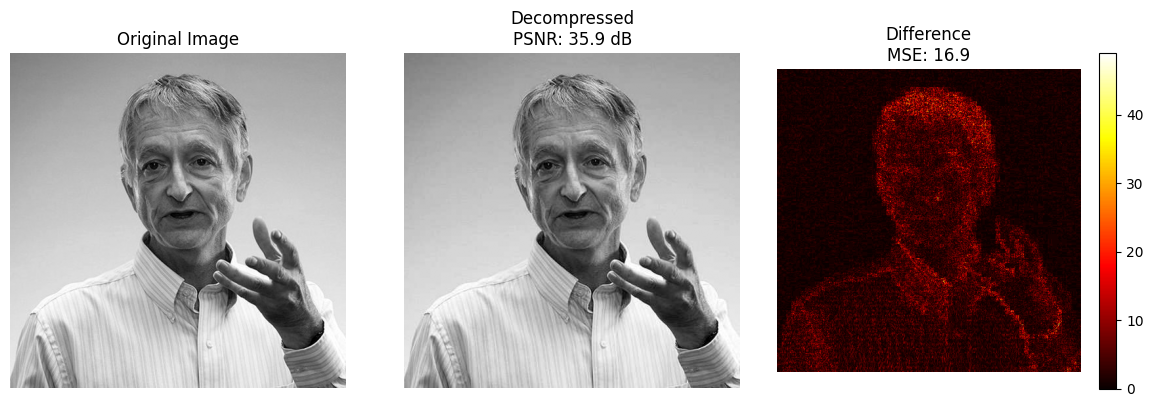

 RealImage test results saved as 'real_image_compression.png'


In [12]:
def test_with_real_image(filename='realimage.jpg'):
    """Test with actual image file"""
    try:
        print(f"Loading real image: {filename}")
        
        # Load image
        original_image = load_and_prepare_image(filename)
        print(f"Image loaded successfully: {original_image.shape}")
        
        # Apply JPEG compression pipeline
        print("Applying JPEG compression...")
        dct_blocks = apply_dct(original_image)
        quantized_blocks = quantize(dct_blocks)
        decompressed_image = apply_idct(quantized_blocks)
        # Calculate metrics
        original_uint8 = np.clip(original_image + 128, 0, 255).astype(np.uint8)
        mse = np.mean((original_uint8.astype(np.float32) - decompressed_image.astype(np.float32))**2)
        psnr = 20 * np.log10(255 / np.sqrt(mse)) if mse > 0 else float('inf')
        
        print(f"decompression completed!")
        print(f"MSE: {mse:.2f}, PSNR: {psnr:.2f} dB")
        
        # Save comparison
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 3, 1)
        plt.imshow(original_uint8, cmap='gray')
        plt.title('Original Image')
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(decompressed_image, cmap='gray')
        plt.title(f'Decompressed\nPSNR: {psnr:.1f} dB')
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        diff = np.abs(original_uint8.astype(np.float32) - decompressed_image.astype(np.float32))
        plt.imshow(diff, cmap='hot')
        plt.title(f'Difference\nMSE: {mse:.1f}')
        plt.axis('off')
        plt.colorbar()
        
        plt.tight_layout()
        plt.savefig('real_image_compression.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(" RealImage test results saved as 'real_image_compression.png'")
        
        return True
        
    except Exception as e:
        print(f"Could not load {filename}: {e}")
        print("Please make sure the image file exists in the current directory.")
        return False

# Try to test with real image
real_image_success = test_with_real_image()